In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Um ressonador

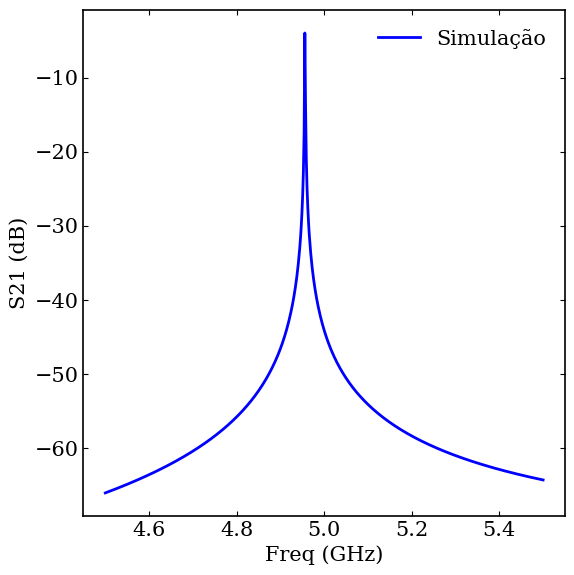

In [21]:
data = np.loadtxt('S21 um ressonador - produzido na china.txt').T

# ---------- Figura ----------
fig, ax = plt.subplots(figsize=(6,6))

ax.plot(data[0], data[1], '-b', label="Simulação")

# ---------- Eixos ----------
ax.set_xlabel("Freq (GHz)")
ax.set_ylabel("S21 (dB)")

# ---------- Limites ----------
#ax.set_xlim(4.6, 5.2)
#ax.set_ylim(-100,-10)

# ---------- Grade opcional ----------
#ax.grid(alpha=0.3)

# ---------- Legenda ----------
ax.legend()

# ---------- Ajuste layout ----------
plt.tight_layout()

# ---------- Salvar figura ----------
#plt.savefig("grafico_artigo.png", dpi=600)

plt.show()

# 2 ressonadores acoplados indutivamente

Posições dos picos: [4.8987976  4.93186373]


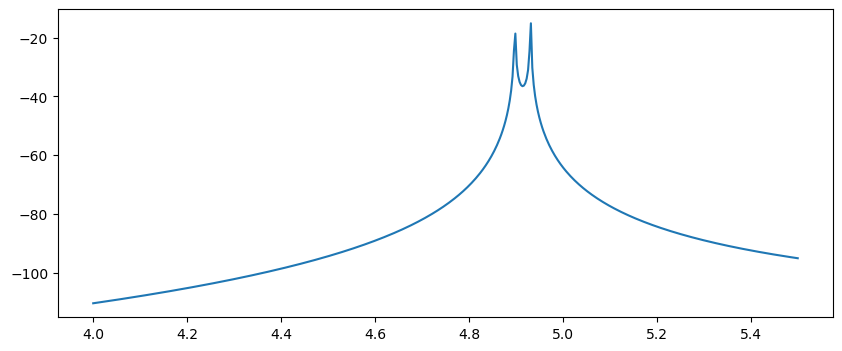

In [2]:
data = np.loadtxt('S21 dois ressoanadores acoplados - produzido na china.txt').T

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(data[0],data[1])
#ax.set_ylim(-70,0)

#################################################
# Encontrar todos os picos
peaks, _ = find_peaks(data[1])

# Ordenar os picos pela altura
indices_maiores = peaks[np.argsort(data[1][peaks])[-2:]]

# Posições dos dois maiores picos
x_picos = data[0][indices_maiores]
y_picos = data[1][indices_maiores]

print("Posições dos picos:", x_picos)


In [3]:
f_ghz=4.9# + 0.014 # GHz segundo harmonico
f=f_ghz*1e9 # Hz
C=np.array([7.267])*1e-15 #F
l= 12*1e-3 # m
C_l=1.7e-10 # F/m
Z=50

t= -(1/2 * f*C*2/(C_l*l))*1e-9

t

array([-0.01745505])

In [4]:

indexes = [(0,1),(1,0)]
ALG = -np.zeros((2,2))

n = 0
for i in range(0,1):
    ALG[indexes[i][0]][indexes[i][1]] = t[n]
    n += 1
n = 0
for i in range(1,2):
    ALG[indexes[i][0]][indexes[i][1]] = t[n]
    n += 1

diagonal = f_ghz*np.ones(2)
H = -ALG
np.fill_diagonal(H,diagonal)

eigenv = np.sort(np.linalg.eigvals(H))
print(H, eigenv)

[[4.9        0.01745505]
 [0.01745505 4.9       ]] [4.88254495 4.91745505]


(4.8, 5.0)

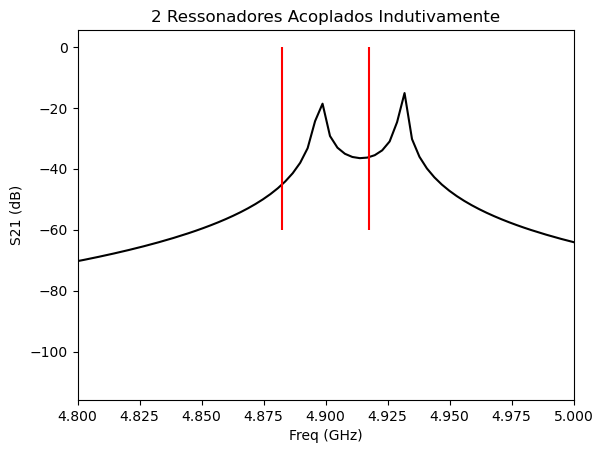

In [5]:
plt.plot(data[0],data[1], 'k')
plt.vlines(eigenv,-60, 0, 'r')
plt.xlabel('Freq (GHz)')
plt.ylabel('S21 (dB)')
plt.title('2 Ressonadores Acoplados Indutivamente')

plt.xlim(4.8,5)

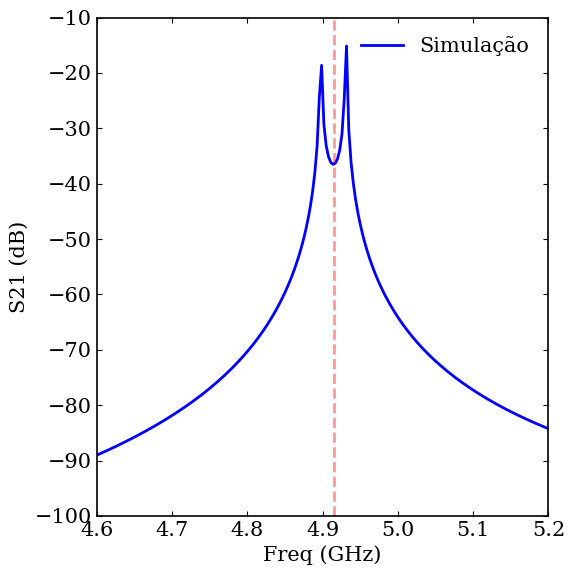

In [9]:
# ---------- Configuração estilo científico ----------
plt.rcParams.update({
    "font.size": 15,
    "font.family": "serif",
    "axes.linewidth": 1.2,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False
})

# ---------- Figura ----------
fig, ax = plt.subplots(figsize=(6,6))

ax.plot(data[0], data[1], '-b', label="Simulação")

# ---------- Valores esperados ----------
f0 = [4.915]
for i, val in enumerate(f0):
    plt.axvline(val, linestyle="--", color="red",
                alpha=0.4,
                label="" if i==0 else "")

# ---------- Eixos ----------
ax.set_xlabel("Freq (GHz)")
ax.set_ylabel("S21 (dB)")

# ---------- Limites ----------
ax.set_xlim(4.6, 5.2)
ax.set_ylim(-100,-10)

# ---------- Grade opcional ----------
#ax.grid(alpha=0.3)

# ---------- Legenda ----------
ax.legend()

# ---------- Ajuste layout ----------
plt.tight_layout()

# ---------- Salvar figura ----------
plt.savefig("grafico_artigo.png", dpi=600)

plt.show()

# 3 ressonadores acoplamento indutivo

Posições dos picos: [13.91702838 14.17345576]


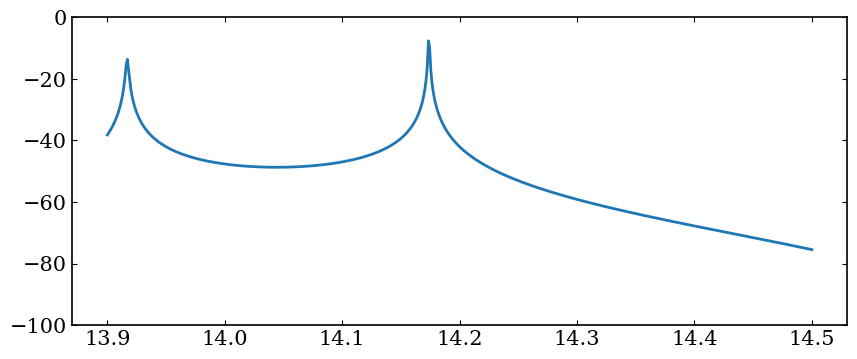

In [14]:
data3 = np.loadtxt('S21 3 ressonadores acopplamento indutivo segundo modo.txt').T

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(data3[0],data3[1])
ax.set_ylim(-100,0)

#################################################
# Encontrar todos os picos
peaks, _ = find_peaks(data3[1])

# Ordenar os picos pela altura
indices_maiores = peaks[np.argsort(data3[1][peaks])[-3:]]

# Posições dos dois maiores picos
x_picos = data3[0][indices_maiores]
y_picos = data3[1][indices_maiores]

print("Posições dos picos:", x_picos)


In [15]:
f_ghz=14.3 - 0.3# - 0.214 # GHz segundo harmonico
f=f_ghz*1e9 # Hz
C=np.array([6.58, 6.57, 6.84])*1e-15# + 2e-15 #F
l= 8.32*1e-3 # m
C_l=1.7e-10 # F/m
Z=50

t= -(1/2 * f*C*2/(C_l*l))*1e-9

t

array([-0.06513009, -0.06503111, -0.06770362])

In [16]:

indexes = [(0,1),(1,2),(2,0),(1,0),(2,1),(0,2)]
ALG = -np.zeros((3,3))

n = 0
for i in range(0,3):
    ALG[indexes[i][0]][indexes[i][1]] = t[n]
    n += 1
n = 0
for i in range(3,6):
    ALG[indexes[i][0]][indexes[i][1]] = t[n]
    n += 1

diagonal = f_ghz*np.ones(6)
H = -ALG
np.fill_diagonal(H,diagonal)

eigenv = np.sort(np.linalg.eigvals(H))
print(H, eigenv)

[[14.          0.06513009  0.06770362]
 [ 0.06513009 14.          0.06503111]
 [ 0.06770362  0.06503111 14.        ]] [13.93229543 13.93578689 14.13191768]


(13.85, 14.5)

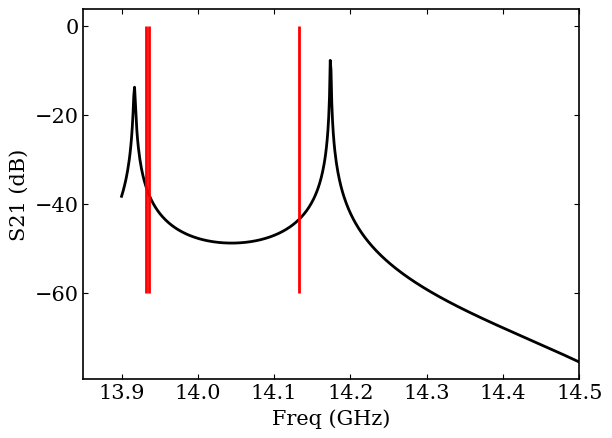

In [26]:
plt.plot(data3[0],data3[1], 'k')
plt.vlines(eigenv,-60, 0, 'r')
plt.xlabel('Freq (GHz)')
plt.ylabel('S21 (dB)')
#plt.title('3 Ressonadores Acoplados Indutivamente')

plt.xlim(13.85,14.5)

# Um ressonador do hexagono

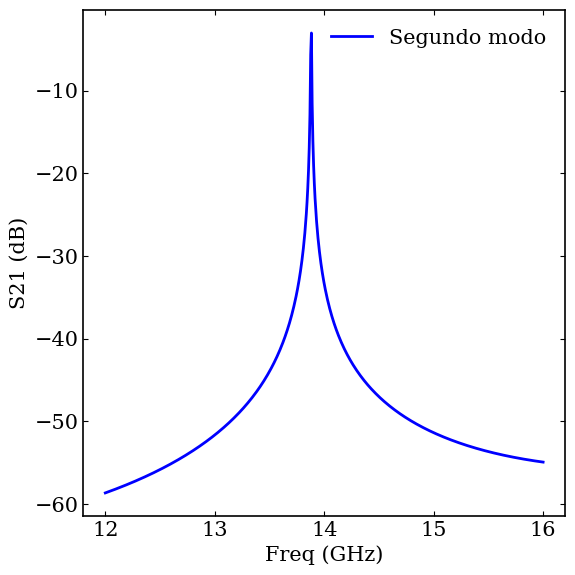

In [13]:
data = np.loadtxt('S21 um ressonador do hexagono.txt').T

# ---------- Figura ----------
fig, ax = plt.subplots(figsize=(6,6))

ax.plot(data[0], data[1], '-b', label="Segundo modo")

# ---------- Eixos ----------
ax.set_xlabel("Freq (GHz)")
ax.set_ylabel("S21 (dB)")

# ---------- Limites ----------
#ax.set_xlim(4.6, 5.2)
#ax.set_ylim(-100,-10)

# ---------- Grade opcional ----------
#ax.grid(alpha=0.3)

# ---------- Legenda ----------
ax.legend()

# ---------- Ajuste layout ----------
plt.tight_layout()

# ---------- Salvar figura ----------
#plt.savefig("grafico_artigo.png", dpi=600)

plt.show()